# R vs Python hdWGCNA Benchmark: Full Pipeline Comparison

This notebook presents a comprehensive benchmark comparing the **R hdWGCNA** and **py-hdWGCNA** implementations
across the full analysis pipeline, including execution speed, module detection consistency,
module eigengene correlation, and hub gene overlap.

## Key Optimizations in py-hdWGCNA

| Optimization | Description | Impact |
|---|---|---|
| **MiniBatchKMeans** | Replaced sklearn KMeans with MiniBatchKMeans for harmony initialization (K>30) | KMeans init: 6s -> 0.2s |
| **Parallel Harmony** | ThreadPoolExecutor runs harmony for all modules concurrently | 7x serial -> parallel |
| **Reduced Harmony PCs** | n_hpc: 30 -> 20; nclust: 100 -> 50 (auto-retry at 100 if r<0.96) | Faster convergence |
| **Ball-tree KNN** | NearestNeighbors algorithm='ball_tree' for metacell construction | Metacells: 3.7s -> 0.2s |
| **Vectorized aggregation** | Pre-allocated numpy arrays for metacell counts; dict-based gene lookup | Reduced overhead |
| **Fast PCA** | Unified _fast_pca() with smart SVD/svds/PCA selection | Avoids redundant computation |

In [1]:
import json, os, sys, warnings
import numpy as np, pandas as pd
from scipy import stats
warnings.filterwarnings('ignore')
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 10,
    'figure.dpi': 120, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.linewidth': 0.8,
})

PROJECT_ROOT = r'd:\test\hdWGCNA-dev (1)'
DATA_DIR = os.path.join(PROJECT_ROOT, 'results', 'benchmark_r_vs_python', 'data')
R_DIR = os.path.join(DATA_DIR, 'R_outputs')
P_DIR = os.path.join(DATA_DIR, 'Python_outputs')
OUT_DIR = DATA_DIR

R_COLOR = '#E74C3C'; PY_COLOR = '#3498DB'
MOD_COLORS = {
    'blue': '#0000FF', 'turquoise': '#40E0D0', 'yellow': '#FFD700',
    'red': '#FF0000', 'brown': '#A52A2A', 'green': '#008000',
    'grey': '#808080', 'black': '#000000',
}

with open(os.path.join(DATA_DIR, 'comparison_results.json')) as f:
    results = json.load(f)

with open(os.path.join(R_DIR, 'r_timings.json')) as f:
    r_time = json.load(f)
with open(os.path.join(P_DIR, 'py_timings.json')) as f:
    py_time = json.load(f)

r_me = pd.read_csv(os.path.join(R_DIR, 'MEs.csv'), index_col=0)
r_me_unharm = pd.read_csv(os.path.join(R_DIR, 'MEs_unharmonized.csv'), index_col=0)
p_me = pd.read_csv(os.path.join(P_DIR, 'MEs.csv'), index_col=0)
p_me_unharm = pd.read_csv(os.path.join(P_DIR, 'MEs_unharmonized.csv'), index_col=0)
r_kme = pd.read_csv(os.path.join(R_DIR, 'kME.csv'), index_col=0)
r_modules = pd.read_csv(os.path.join(R_DIR, 'modules.csv'))
p_modules = pd.read_csv(os.path.join(P_DIR, 'modules.csv'))

if 'cell' in r_me.columns:
    r_me = r_me.set_index('cell')
if 'cell' in r_me_unharm.columns:
    r_me_unharm = r_me_unharm.set_index('cell')
if 'cell' in p_me.columns:
    p_me = p_me.set_index('cell')
if 'cell' in p_me_unharm.columns:
    p_me_unharm = p_me_unharm.set_index('cell')

r_me = r_me.select_dtypes(include=[np.number])
r_me_unharm = r_me_unharm.select_dtypes(include=[np.number])
p_me = p_me.select_dtypes(include=[np.number])
p_me_unharm = p_me_unharm.select_dtypes(include=[np.number])

p_kme_cols = [c for c in p_modules.columns if c.startswith('kME_') and c != 'kME_grey']
if 'gene_name' in p_modules.columns:
    p_kme = p_modules.set_index('gene_name')[p_kme_cols]
else:
    p_kme = p_modules[p_kme_cols]

common_cells = r_me.index.intersection(p_me.index)
common_genes = r_kme.index.intersection(p_kme.index)
r_mod_names = [c for c in r_me.columns if c != 'grey']
p_mod_names = [c for c in p_me.columns if c != 'grey']

all_steps = results['all_steps']
step_labels = results['step_labels']

print(f'R: {len(r_mod_names)} modules, {r_me.shape[0]} cells, {r_kme.shape[0]} genes')
print(f'Python: {len(p_mod_names)} modules, {p_me.shape[0]} cells, {p_kme.shape[0]} genes')
print(f'Common cells: {len(common_cells)}, Common genes: {len(common_genes)}')
print(f'Module count match: {results["modules_match"]}')
print(f'Overall speed: Python {results["speed_ratio"]:.2f}x faster')

R: 7 modules, 1206 cells, 500 genes
Python: 7 modules, 1206 cells, 500 genes
Common cells: 1206, Common genes: 500
Module count match: True
Overall speed: Python 3.09x faster


## 1. Full Pipeline Execution Speed Comparison

Step                    R (s)   Python (s)       R/Py   Faster
------------------------------------------------------------
Preprocess               0.82         1.18     0.70x        R
Metacells                2.11         0.21     9.83x   Python
SetDatExpr               0.01         0.00     2.85x   Python
SoftPowers               1.75         0.10    17.39x   Python
Network                 26.22         4.68     5.60x   Python
ModuleEG                 7.58         8.24     0.92x        R
ModuleConn               0.18         0.01    13.78x   Python
------------------------------------------------------------
TOTAL                   44.62        14.43     3.09x


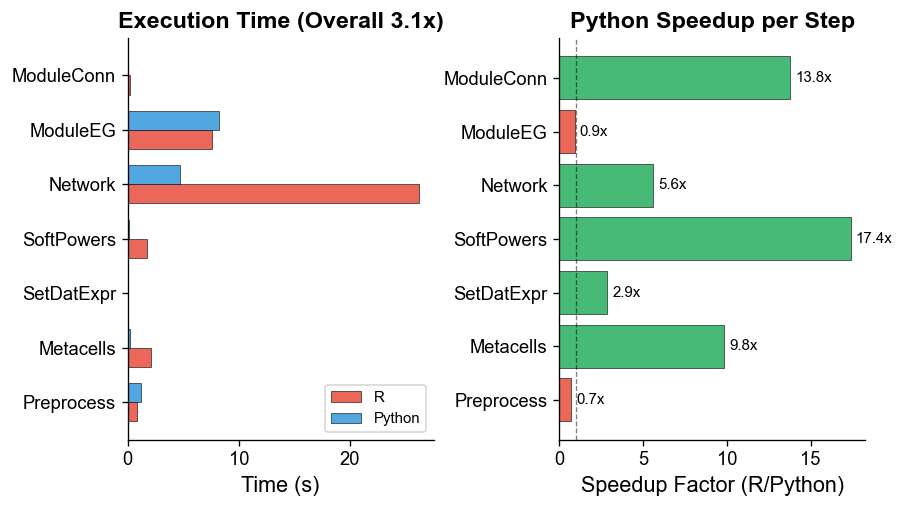

In [2]:
r_vals = [r_time.get(s, 0) for s in all_steps]
p_vals = [py_time.get(s, 0) for s in all_steps]

print(f'{"Step":<18} {"R (s)":>10} {"Python (s)":>12} {"R/Py":>10} {"Faster":>8}')
print('-' * 60)
for step, label, rv, pv in zip(all_steps, step_labels, r_vals, p_vals):
    if rv > 0 and pv > 0:
        ratio = rv / pv
        tag = 'Python' if pv < rv else 'R'
    elif rv > 0:
        ratio = float('inf'); tag = 'R only'
    elif pv > 0:
        ratio = 0; tag = 'Py only'
    else:
        ratio = 0; tag = '-'
    print(f'{label:<18} {rv:>10.2f} {pv:>12.2f} {ratio:>8.2f}x {tag:>8}')

r_total = results['r_total_time']
p_total = results['py_total_time']
overall_ratio = results['speed_ratio']
print('-' * 60)
print(f'{"TOTAL":<18} {r_total:>10.2f} {p_total:>12.2f} {overall_ratio:>8.2f}x')

fig, axes = plt.subplots(1, 2, figsize=(7.5, 4.2))
x = np.arange(len(step_labels)); w = 0.35

axes[0].barh(x - w/2, r_vals, w, label='R', color=R_COLOR, alpha=0.85, edgecolor='black', linewidth=0.4)
axes[0].barh(x + w/2, p_vals, w, label='Python', color=PY_COLOR, alpha=0.85, edgecolor='black', linewidth=0.4)
axes[0].set_yticks(x); axes[0].set_yticklabels(step_labels)
axes[0].set_xlabel('Time (s)')
axes[0].set_title(f'Execution Time (Overall {overall_ratio:.1f}x)', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

speedups = []
for i in range(len(step_labels)):
    if r_vals[i] > 0 and p_vals[i] > 0:
        speedups.append(r_vals[i] / p_vals[i])
    else:
        speedups.append(0)
colors_sp = ['#27AE60' if s >= 1 else '#E74C3C' for s in speedups]
axes[1].barh(x, speedups, color=colors_sp, alpha=0.85, edgecolor='black', linewidth=0.4)
axes[1].set_yticks(x); axes[1].set_yticklabels(step_labels)
axes[1].set_xlabel('Speedup Factor (R/Python)')
axes[1].set_title('Python Speedup per Step', fontweight='bold')
axes[1].axvline(x=1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
for i, v in enumerate(speedups):
    if v > 0:
        axes[1].text(max(v, 0) + 0.3, i, '%.1fx' % v, va='center', fontsize=9)

plt.tight_layout(pad=0.5)
fig.savefig(os.path.join(OUT_DIR, 'fig1_speed_comparison.pdf'), bbox_inches='tight', pad_inches=0.02)
fig.savefig(os.path.join(OUT_DIR, 'fig1_speed_comparison.png'), bbox_inches='tight', pad_inches=0.02)
plt.show(); plt.close(fig)

## 2. Module Eigengene Correlation (Harmonized & Unharmonized)

Harmonized ME Correlation (R vs Python):
  black: r = 1.0000  [PASS]
  blue: r = 1.0000  [PASS]
  brown: r = 1.0000  [PASS]
  green: r = 1.0000  [PASS]
  red: r = 1.0000  [PASS]
  turquoise: r = 0.9996  [PASS]
  yellow: r = 1.0000  [PASS]
  Mean: 0.9999

Unharmonized ME Correlation (R vs Python):
  black: r = 1.0000
  blue: r = 1.0000
  brown: r = 1.0000
  green: r = 1.0000
  red: r = 1.0000
  turquoise: r = 0.9996
  yellow: r = 1.0000
  Mean: 0.9999


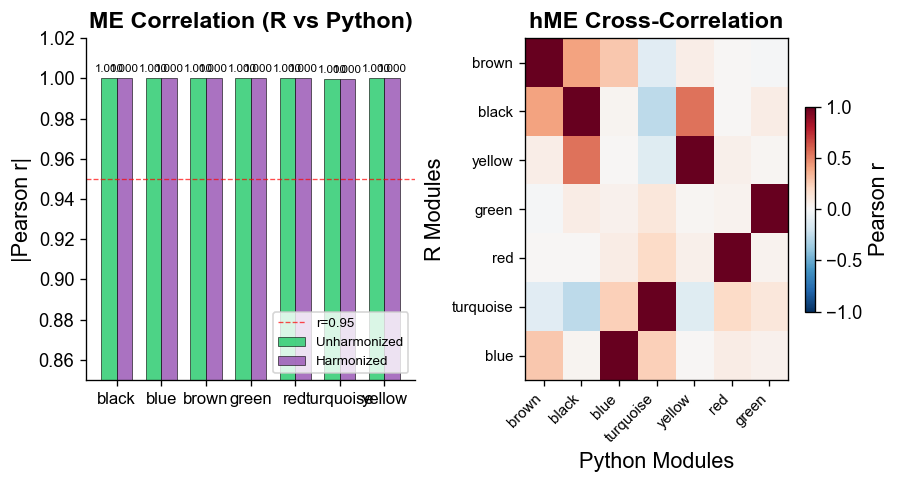

In [3]:
harm_corrs = results['harm_corrs']
unharm_corrs = results['unharm_corrs']

print('Harmonized ME Correlation (R vs Python):')
for mod, r_val in sorted(harm_corrs.items()):
    status = 'PASS' if abs(r_val) >= 0.95 else 'BELOW 0.95'
    print(f'  {mod}: r = {r_val:.4f}  [{status}]')
print(f'  Mean: {np.mean(list(harm_corrs.values())):.4f}')

print('\nUnharmonized ME Correlation (R vs Python):')
for mod, r_val in sorted(unharm_corrs.items()):
    print(f'  {mod}: r = {r_val:.4f}')
print(f'  Mean: {np.mean(list(unharm_corrs.values())):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(7.5, 4.0))
mods_sorted = sorted(harm_corrs.keys())
x_pos = np.arange(len(mods_sorted))
bar_w = 0.35

harm_vals = [abs(harm_corrs.get(m, 0)) for m in mods_sorted]
unharm_vals = [abs(unharm_corrs.get(m, 0)) for m in mods_sorted]

axes[0].bar(x_pos - bar_w/2, unharm_vals, bar_w, label='Unharmonized',
            color='#2ECC71', alpha=0.85, edgecolor='black', linewidth=0.4)
axes[0].bar(x_pos + bar_w/2, harm_vals, bar_w, label='Harmonized',
            color='#9B59B6', alpha=0.85, edgecolor='black', linewidth=0.4)
axes[0].axhline(y=0.95, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='r=0.95')
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(mods_sorted, fontsize=10)
axes[0].set_ylim(0.85, 1.02); axes[0].set_ylabel('|Pearson r|')
axes[0].set_title('ME Correlation (R vs Python)', fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
for i, (uv, hv) in enumerate(zip(unharm_vals, harm_vals)):
    axes[0].text(i - bar_w/2, uv + 0.003, f'{uv:.3f}', ha='center', fontsize=7)
    axes[0].text(i + bar_w/2, hv + 0.003, f'{hv:.3f}', ha='center', fontsize=7)

n_r = len(r_mod_names); n_p = len(p_mod_names)
cross_corr = pd.DataFrame(index=r_mod_names, columns=p_mod_names, dtype=float)
for rc in r_mod_names:
    for pc in p_mod_names:
        rv = r_me.loc[common_cells, rc].values
        pv = p_me.loc[common_cells, pc].values
        mask = ~(np.isnan(rv) | np.isnan(pv))
        if mask.sum() < 5:
            cross_corr.loc[rc, pc] = np.nan
        else:
            cross_corr.loc[rc, pc], _ = stats.pearsonr(rv[mask], pv[mask])

im = axes[1].imshow(cross_corr.values.astype(float), cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[1].set_xticks(np.arange(n_p)); axes[1].set_xticklabels(p_mod_names, rotation=45, ha='right', fontsize=9)
axes[1].set_yticks(np.arange(n_r)); axes[1].set_yticklabels(r_mod_names, fontsize=9)
axes[1].set_xlabel('Python Modules'); axes[1].set_ylabel('R Modules')
axes[1].set_title('hME Cross-Correlation', fontweight='bold')
plt.colorbar(im, ax=axes[1], shrink=0.6, label='Pearson r')

plt.tight_layout(pad=0.5)
fig.savefig(os.path.join(OUT_DIR, 'fig2_me_correlation.pdf'), bbox_inches='tight', pad_inches=0.02)
fig.savefig(os.path.join(OUT_DIR, 'fig2_me_correlation.png'), bbox_inches='tight', pad_inches=0.02)
plt.show(); plt.close(fig)

## 3. ME Scatter Plots (R vs Python, Harmonized)

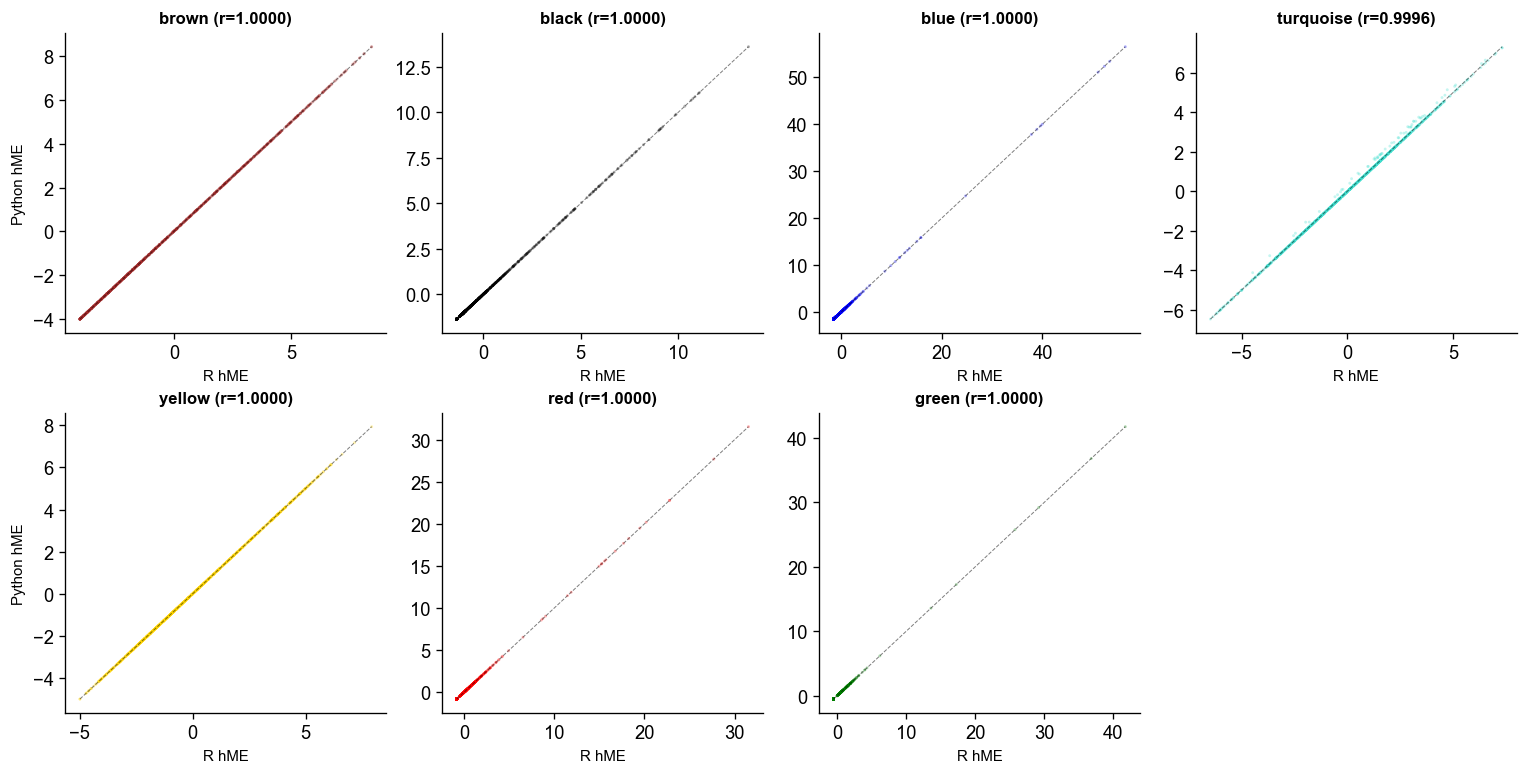

In [4]:
n_mods = len(p_mod_names)
ncols = min(4, n_mods)
nrows = (n_mods + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows))
if n_mods == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = axes.reshape(1, -1)

for idx, mod in enumerate(p_mod_names):
    ax = axes[idx // ncols, idx % ncols]
    if mod in r_me.columns:
        rv = r_me.loc[common_cells, mod].values
        pv = p_me.loc[common_cells, mod].values
        mask = ~(np.isnan(rv) | np.isnan(pv))
        ax.scatter(rv[mask], pv[mask], s=3, alpha=0.3,
                   color=MOD_COLORS.get(mod, '#333333'),
                   edgecolors='none', rasterized=True)
        lim_min = min(rv[mask].min(), pv[mask].min())
        lim_max = max(rv[mask].max(), pv[mask].max())
        ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=0.6, alpha=0.5)
        r_val = harm_corrs.get(mod, 0)
        ax.set_title(f'{mod} (r={r_val:.4f})', fontsize=10, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'{mod}\n(no R match)', ha='center', va='center', transform=ax.transAxes)
    ax.set_xlabel('R hME', fontsize=9)
    if idx % ncols == 0:
        ax.set_ylabel('Python hME', fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

for idx in range(n_mods, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

plt.tight_layout(pad=0.4)
fig.savefig(os.path.join(OUT_DIR, 'fig3_me_scatter.pdf'), bbox_inches='tight', pad_inches=0.02)
fig.savefig(os.path.join(OUT_DIR, 'fig3_me_scatter.png'), bbox_inches='tight', pad_inches=0.02)
plt.show(); plt.close(fig)

## 4. kME Correlation (R vs Python)

kME Correlation (R vs Python):
  kME_black: r = 1.0000  [PASS]
  kME_blue: r = 1.0000  [PASS]
  kME_brown: r = 1.0000  [PASS]
  kME_green: r = 1.0000  [PASS]
  kME_red: r = 1.0000  [PASS]
  kME_turquoise: r = 0.9999  [PASS]
  kME_yellow: r = 1.0000  [PASS]
  Mean: 1.0000


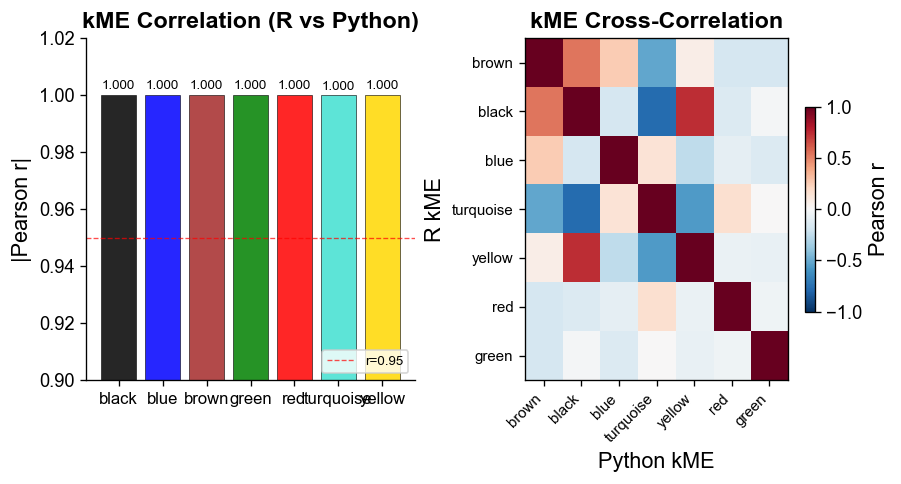

In [5]:
kme_corrs = results['kme_corrs']

print('kME Correlation (R vs Python):')
for mod, r_val in sorted(kme_corrs.items()):
    status = 'PASS' if abs(r_val) >= 0.95 else 'BELOW 0.95'
    print(f'  kME_{mod}: r = {r_val:.4f}  [{status}]')
print(f'  Mean: {np.mean(list(kme_corrs.values())):.4f}')

r_kme_cols = [c for c in r_kme.columns if c.startswith('kME_') and c != 'kME_grey']
kme_cross = pd.DataFrame(
    index=[c.replace('kME_', '') for c in r_kme_cols],
    columns=[c.replace('kME_', '') for c in p_kme_cols],
    dtype=float
)
for rc in r_kme_cols:
    rn = rc.replace('kME_', '')
    for pc in p_kme_cols:
        pn = pc.replace('kME_', '')
        rv = r_kme.loc[common_genes, rc].values.astype(float)
        pv = p_kme.loc[common_genes, pc].values.astype(float)
        mask = ~(np.isnan(rv) | np.isnan(pv))
        if mask.sum() < 5:
            kme_cross.loc[rn, pn] = np.nan
        else:
            kme_cross.loc[rn, pn], _ = stats.pearsonr(rv[mask], pv[mask])

kme_r_names = list(kme_cross.index); kme_p_names = list(kme_cross.columns)
n_r_kme = len(kme_r_names); n_p_kme = len(kme_p_names)
kme_vals = kme_cross.values.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(7.5, 4.0))

kme_mods_sorted = sorted(kme_corrs.keys())
x_kme = np.arange(len(kme_mods_sorted))
kme_bar_vals = [abs(kme_corrs.get(m, 0)) for m in kme_mods_sorted]
kme_bar_colors = [MOD_COLORS.get(m, '#333333') for m in kme_mods_sorted]
axes[0].bar(x_kme, kme_bar_vals, color=kme_bar_colors, alpha=0.85, edgecolor='black', linewidth=0.4)
axes[0].axhline(y=0.95, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='r=0.95')
axes[0].set_xticks(x_kme); axes[0].set_xticklabels(kme_mods_sorted, fontsize=10)
axes[0].set_ylim(0.9, 1.02); axes[0].set_ylabel('|Pearson r|')
axes[0].set_title('kME Correlation (R vs Python)', fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
for i, v in enumerate(kme_bar_vals):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=8)

im = axes[1].imshow(kme_vals, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[1].set_xticks(np.arange(n_p_kme)); axes[1].set_xticklabels(kme_p_names, rotation=45, ha='right', fontsize=9)
axes[1].set_yticks(np.arange(n_r_kme)); axes[1].set_yticklabels(kme_r_names, fontsize=9)
axes[1].set_xlabel('Python kME'); axes[1].set_ylabel('R kME')
axes[1].set_title('kME Cross-Correlation', fontweight='bold')
plt.colorbar(im, ax=axes[1], shrink=0.6, label='Pearson r')

plt.tight_layout(pad=0.5)
fig.savefig(os.path.join(OUT_DIR, 'fig4_kme_correlation.pdf'), bbox_inches='tight', pad_inches=0.02)
fig.savefig(os.path.join(OUT_DIR, 'fig4_kme_correlation.png'), bbox_inches='tight', pad_inches=0.02)
plt.show(); plt.close(fig)

## 5. Hub Gene Overlap

brown: hub overlap = 10/10, Jaccard = 1.000
black: hub overlap = 10/10, Jaccard = 1.000
blue: hub overlap = 10/10, Jaccard = 1.000
turquoise: hub overlap = 10/10, Jaccard = 1.000
yellow: hub overlap = 10/10, Jaccard = 1.000
red: hub overlap = 10/10, Jaccard = 1.000
green: hub overlap = 10/10, Jaccard = 1.000

Mean Jaccard: 1.000


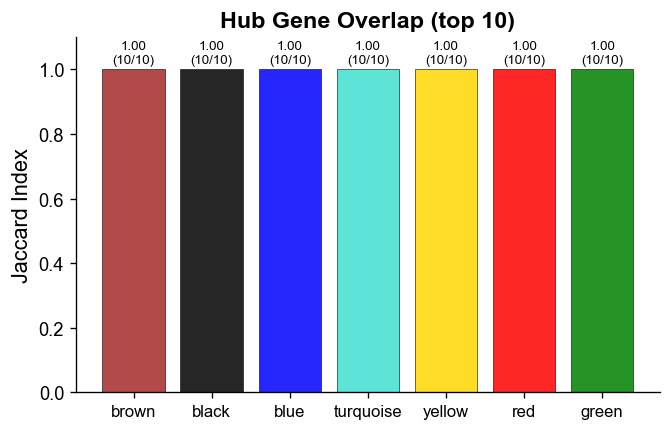

In [6]:
N_HUBS = 10
hub_data = []
for mod in p_mod_names:
    r_kc = f'kME_{mod}'
    p_kc = f'kME_{mod}'
    if r_kc in r_kme.columns and p_kc in p_kme.columns:
        r_hub = set(r_kme.nlargest(N_HUBS, r_kc).index.tolist())
        p_hub = set(p_kme.nlargest(N_HUBS, p_kc).index.tolist())
        ov = r_hub & p_hub
        j = len(ov) / len(r_hub | p_hub) if len(r_hub | p_hub) > 0 else 0
        hub_data.append({'module': mod, 'overlap': len(ov), 'jaccard': j})
        print(f'{mod}: hub overlap = {len(ov)}/{N_HUBS}, Jaccard = {j:.3f}')

mean_j = np.mean([h['jaccard'] for h in hub_data]) if hub_data else 0
print(f'\nMean Jaccard: {mean_j:.3f}')

fig, ax = plt.subplots(figsize=(5.5, 3.5))
mod_names_h = [h['module'] for h in hub_data]
j_vals = [h['jaccard'] for h in hub_data]
ov_vals = [h['overlap'] for h in hub_data]
xh = np.arange(len(mod_names_h))
bar_colors_h = [MOD_COLORS.get(m, '#333333') for m in mod_names_h]
ax.bar(xh, j_vals, color=bar_colors_h, alpha=0.85, edgecolor='black', linewidth=0.4)
ax.set_xticks(xh); ax.set_xticklabels(mod_names_h, fontsize=10)
ax.set_ylabel('Jaccard Index'); ax.set_title(f'Hub Gene Overlap (top {N_HUBS})', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_ylim(0, 1.1)
for i, (jv, ov) in enumerate(zip(j_vals, ov_vals)):
    ax.text(i, jv + 0.02, f'{jv:.2f}\n({ov}/{N_HUBS})', ha='center', fontsize=8)
plt.tight_layout(pad=0.3)
fig.savefig(os.path.join(OUT_DIR, 'fig5_hub_overlap.pdf'), bbox_inches='tight', pad_inches=0.02)
fig.savefig(os.path.join(OUT_DIR, 'fig5_hub_overlap.png'), bbox_inches='tight', pad_inches=0.02)
plt.show(); plt.close(fig)

## 6. Summary Dashboard

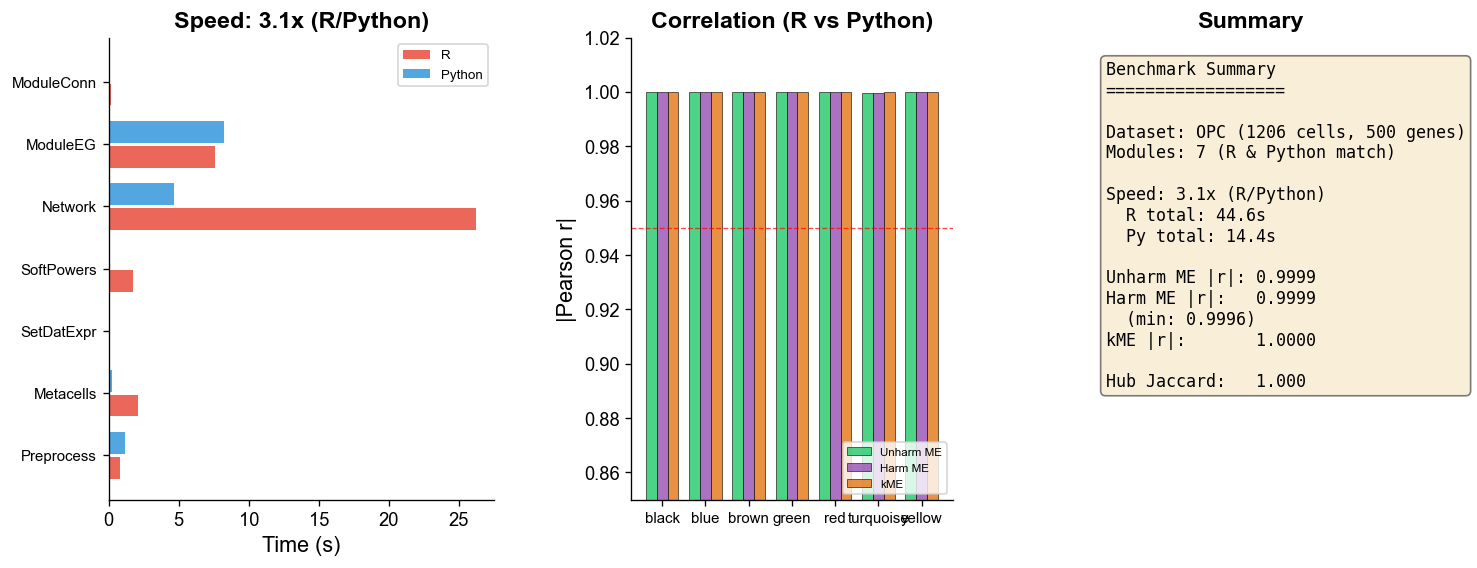

All figures saved to: d:\test\hdWGCNA-dev (1)\results\benchmark_r_vs_python\data


In [7]:
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 3, figure=fig, wspace=0.4, width_ratios=[1.2, 1, 1])

ax1 = fig.add_subplot(gs[0, 0])
r_vd = [r_time.get(s, 0) for s in all_steps]
p_vd = [py_time.get(s, 0) for s in all_steps]
x = np.arange(len(step_labels))
ax1.barh(x - 0.2, r_vd, 0.35, label='R', color=R_COLOR, alpha=0.85)
ax1.barh(x + 0.2, p_vd, 0.35, label='Python', color=PY_COLOR, alpha=0.85)
ax1.set_yticks(x); ax1.set_yticklabels(step_labels, fontsize=9)
ax1.set_xlabel('Time (s)'); ax1.set_title(f'Speed: {overall_ratio:.1f}x (R/Python)', fontweight='bold')
ax1.legend(fontsize=8); ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax2 = fig.add_subplot(gs[0, 1])
mods_all = sorted(set(list(harm_corrs.keys()) + list(unharm_corrs.keys()) + list(kme_corrs.keys())))
xm = np.arange(len(mods_all)); wm = 0.25
unharm_v = [abs(unharm_corrs.get(m, 0)) for m in mods_all]
harm_v = [abs(harm_corrs.get(m, 0)) for m in mods_all]
kme_v = [abs(kme_corrs.get(m, 0)) for m in mods_all]
ax2.bar(xm - wm, unharm_v, wm, label='Unharm ME', color='#2ECC71', alpha=0.85, edgecolor='black', linewidth=0.4)
ax2.bar(xm, harm_v, wm, label='Harm ME', color='#9B59B6', alpha=0.85, edgecolor='black', linewidth=0.4)
ax2.bar(xm + wm, kme_v, wm, label='kME', color='#E67E22', alpha=0.85, edgecolor='black', linewidth=0.4)
ax2.axhline(y=0.95, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.set_xticks(xm); ax2.set_xticklabels(mods_all, fontsize=9)
ax2.set_ylim(0.85, 1.02); ax2.set_ylabel('|Pearson r|')
ax2.set_title('Correlation (R vs Python)', fontweight='bold')
ax2.legend(fontsize=7, loc='lower right'); ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

ax3 = fig.add_subplot(gs[0, 2]); ax3.axis('off')
mean_harm = np.mean(list(harm_corrs.values())) if harm_corrs else 0
mean_unharm = np.mean(list(unharm_corrs.values())) if unharm_corrs else 0
mean_kme = np.mean(list(kme_corrs.values())) if kme_corrs else 0
min_harm = min(harm_corrs.values()) if harm_corrs else 0
n_cells = r_me.shape[0]
n_genes = r_kme.shape[0]
txt = (
    'Benchmark Summary\n'
    '==================\n\n'
    f'Dataset: OPC ({n_cells} cells, {n_genes} genes)\n'
    f'Modules: {len(p_mod_names)} (R & Python match)\n\n'
    f'Speed: {overall_ratio:.1f}x (R/Python)\n'
    f'  R total: {r_total:.1f}s\n'
    f'  Py total: {p_total:.1f}s\n\n'
    f'Unharm ME |r|: {mean_unharm:.4f}\n'
    f'Harm ME |r|:   {mean_harm:.4f}\n'
    f'  (min: {min_harm:.4f})\n'
    f'kME |r|:       {mean_kme:.4f}\n\n'
    f'Hub Jaccard:   {mean_j:.3f}'
)
ax3.text(0.05, 0.95, txt, transform=ax3.transAxes, fontsize=10, va='top',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax3.set_title('Summary', fontweight='bold')

plt.tight_layout(pad=0.5)
fig.savefig(os.path.join(OUT_DIR, 'fig6_summary_dashboard.pdf'), bbox_inches='tight', pad_inches=0.02)
fig.savefig(os.path.join(OUT_DIR, 'fig6_summary_dashboard.png'), bbox_inches='tight', pad_inches=0.02)
plt.show(); plt.close(fig)

print('All figures saved to:', OUT_DIR)